# Getting started with Word2Vec!!

The idea behind Word2Vec is intuitive --- tell the meaning of a word using its neighbors. Two words that have similar neighbors are probably quite similar in meaning (i.e., synonyms) and should lie in the same embedding space.

Here, we will learn how to use the Gensim implementation of Word2Vec!

References

1. https://github.com/kavgan/nlp-in-practice/
2. https://www.analyticsvidhya.com/blog/2019/07/how-to-build-recommendation-system-word2vec-python/

### Imports and logging

First, we start with our imports and get logging established:

In [1]:
import gensim 

### Dataset 
Next, is our dataset. The secret to getting Word2Vec to work is to have lots and lots of text data. We are using data from the magical world of Harry Potter. We have concatenated texts from all the books of Harry Potter into a single .txt file.

We can pass the text as a sequence of sentences to Gensim or directly pass the whole text as a single string.

Gensim: https://radimrehurek.com/gensim/index.html
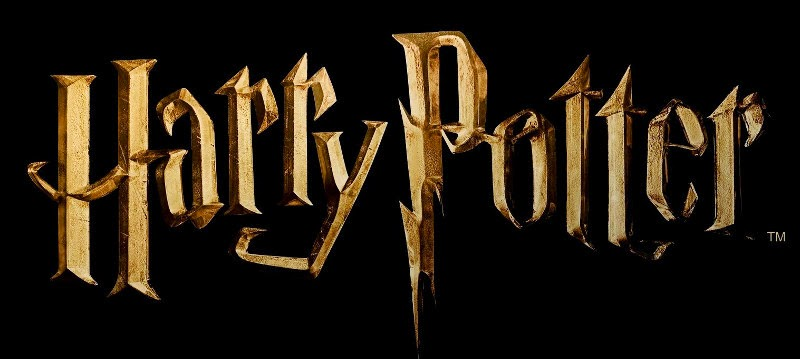

In [2]:
# Load dataset
data = open('./data/harry_potter.txt','r').read()
# data

# Preprocess
import nltk
from nltk.corpus import stopwords
sw_nltk = stopwords.words('english')
print(sw_nltk)

import spacy
#loading the english language small model of spacy
en = spacy.load('en_core_web_sm')
sw_spacy = en.Defaults.stop_words
print(sw_spacy)

# Remove stopwords using NLTK
words = [word for word in data.split() if word.lower() not in sw_nltk]
data = " ".join(words)

# Remove stopwords using Spacy
words = [word for word in data.split() if word.lower() not in sw_spacy]
data = " ".join(words)

# Remove stopwords using Gensim
from gensim.parsing.preprocessing import remove_stopwords
data = remove_stopwords(data)
print(len(open('./data/harry_potter.txt','r').read()), len(data))

['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', '

## Training the Word2Vec model

Training the model is fairly straightforward. You just instantiate Word2Vec and pass the reviews that we read in the previous step (the `documents`). So, we are essentially passing on a list of lists. Where each list within the main list contains a set of tokens from a user review. Word2Vec uses all these tokens to internally create a vocabulary. And by vocabulary, I mean a set of unique words.

Behind the scenes we are actually training a simple neural network with a single hidden layer. But, we are actually not going to use the neural network after training. Instead, the goal is to learn the weights of the hidden layer. These weights are essentially the word vectors that we’re trying to learn. 

In [3]:
## Read files into a list
def read_input(input_file):
    """This method reads the input file which is in gzip format"""

    for i, line in enumerate (input_file.split('.')): 
        # Do some pre-processing and return a list of words for each review text
        yield gensim.utils.simple_preprocess(line)

# read the tokenized reviews into a list
# each review item becomes a series of words
# so this becomes a list of lists
documents = list(read_input(data))
documents

# # Train Word2Vec model
model = gensim.models.Word2Vec(documents, vector_size=100, window=5, min_count=3, workers=10)
model.train(documents,total_examples=len(documents),epochs=50, compute_loss=True)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


(24873260, 27766700)

## Now, let's look at some output 
This first example shows a simple case of looking up `Harry` ofcourse. We simply have to call the `most_similar` function and provide the word `Harry` as the positive example. This returns the top 10 similar words. 

In [4]:
w1 = "harry"
model.wv.most_similar(positive=w1, topn=5)

[('he', 0.8348522782325745),
 ('ron', 0.6230568885803223),
 ('hermione', 0.5625727772712708),
 ('she', 0.4723930060863495),
 ('then', 0.4597182273864746)]

That looks pretty good, right? Let's look at a few more. Let's look at similarity for `ron`, `hermione` and `voldemort`. 

In [5]:
# look up top 6 words similar to 'ron'
w1 = ["ron"]
model.wv.most_similar (positive=w1,topn=5)


[('hermione', 0.6666619181632996),
 ('harry', 0.6230568885803223),
 ('ginny', 0.6050875186920166),
 ('cho', 0.46211662888526917),
 ('rons', 0.4583016633987427)]

In [6]:
# look up top 6 words similar to 'hermione'
w1 = ["hermione"]
model.wv.most_similar (positive=w1,topn=6)


[('ron', 0.6666619181632996),
 ('harry', 0.5625727772712708),
 ('lavender', 0.5559089183807373),
 ('she', 0.5179198980331421),
 ('ginny', 0.45422446727752686),
 ('cho', 0.4365714192390442)]

In [7]:
# look up top 6 words similar to 'voldemort'
w1 = ["voldemort"]
model.wv.most_similar (positive=w1,topn=6)


[('voldemorts', 0.704401433467865),
 ('wormtail', 0.47261807322502136),
 ('prophecy', 0.4622809886932373),
 ('youknowwho', 0.460679829120636),
 ('bertha', 0.4534984827041626),
 ('mmy', 0.43720147013664246)]

This seems fairly good given the storyline. You can even specify several positive examples to get things that are related in the provided context and provide negative examples to say what should not be considered as related. In the example below we are asking for all items that *relate to hogwarts* only:

In [8]:
# get everything related to stuff on the bed
w1 = ['wizards', 'magic', 'hogwarts']
w2 = ['muggles']
model.wv.most_similar (positive=w1,negative=w2,topn=10)


[('codes', 0.47537603974342346),
 ('employees', 0.4639488756656647),
 ('assurances', 0.4469263553619385),
 ('witchcraft', 0.4365529417991638),
 ('wizardry', 0.4350508451461792),
 ('decree', 0.4231112003326416),
 ('official', 0.4086649417877197),
 ('submit', 0.3974567949771881),
 ('departments', 0.3939812183380127),
 ('insider', 0.3929090201854706)]

### Similarity between two words in the vocabulary

You can even use the Word2Vec model to return the similarity between two words that are present in the vocabulary. 

In [9]:
# similarity between two different words
model.wv.similarity(w1="gryffindor",w2="slytherin")

np.float32(0.533474)

In [10]:
# similarity between two identical words
model.wv.similarity(w1="harry",w2="harry")

np.float32(1.0)

In [11]:
# similarity between two unrelated words
model.wv.similarity(w1="dementor",w2="muggle")

np.float32(0.028595917)

Under the hood, the above three snippets compute the cosine similarity between the two specified words using the word vectors of each. From the scores, it makes sense that `gryffindor` is similar to `slytherin` as both are different houses in the Harry Potter universe. If you do a similarity between two identical words, the score will be 1.0 as the range of the cosine similarity score will always be between [0.0-1.0]. You can read more about cosine similarity scoring [here](https://en.wikipedia.org/wiki/Cosine_similarity).

When measuring the similarity between two unrelated words like `dementor` and `muggle`, we obtain very low cosine similarity scores, which is expected.

### Find the odd one out
You can even use Word2Vec to find odd items given a list of items.

In [12]:
# Which one is the odd one out in this list?
model.wv.doesnt_match(["harry","ron","hermione", "voldemort"])

'voldemort'

In [13]:
# Which one is the odd one out in this list?
model.wv.doesnt_match(["hogwart","magic", "wizard", "muggle"])


'wizard'

## Understanding some of the parameters
To train the model earlier, we had to set some parameters. Now, let's try to understand what some of them mean. For reference, this is the command that we used to train the model.

```
model = gensim.models.Word2Vec (documents, vector_size=150, window=10, min_count=2, workers=10)
```

### `vector_size`
The size of the dense vector to represent each token or word. If you have very limited data, then size should be a much smaller value. If you have lots of data, its good to experiment with various sizes.

### `window`
The maximum distance between the target word and its neighboring word. If your neighbor's position is greater than the maximum window width to the left and the right, then, some neighbors are not considered as being related to the target word. In theory, a smaller window should give you more related terms. If you have lots of data, then the window size should not matter too much, as long as it's a decent-sized window. 

### `min_count`
Minimum frequency count of words. The model would ignore words that do not satisfy the `min_count`. Extremely infrequent words are usually unimportant, so it's best to get rid of those. Unless your dataset is tiny, this does not affect the model.

### `workers`
How many threads to use behind the scenes?

### `sg`
Training algorithm: 1 for skip-gram; otherwise CBOW.

### `hs`
If 1, hierarchical softmax will be used for model training. If 0, hierarchical softmax will not be used for model training.

### `negative`
If > 0, negative sampling will be used, the int for negative specifies how many “noise words” should be drawn (usually between 5-20). If 0, negative sampling will not be used.


## When should you use Word2Vec?

There are many application scenarios for Word2Vec. Imagine if you need to build a `sentiment lexicon`. Training a Word2Vec model on large amounts of user reviews helps you achieve that. You have a lexicon for not just sentiment but for most words in the vocabulary. 

## Let's visualize the entire vocabulary using the learned embeddings

We will first extract the vectors of all the words in our vocabulary and store them in one place for easy access.

In [15]:
# Get the ordered list of words in the vocabulary
words = list(w for w in model.wv.index_to_key)

# extract all vectors
embedding = []
for w in words[:1000]:
    embedding.append(model.wv[w])
    
# Visualize word2vec Embeddings
import pandas
import umap.umap_ as umap
import plotly.express as px
import matplotlib.pyplot as plt

cluster_embedding = umap.UMAP(n_neighbors=100, min_dist=0.0,
                              n_components=2, random_state=42).fit_transform(embedding)

fig = px.scatter(x=cluster_embedding[:, 0], y=cluster_embedding[:, 1], color=words[:1000])
fig.show()

/opt/anaconda3/envs/ds6051/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Let's train a Word2Vec model with Negative sampling and compare the visualization

In [16]:
# # Train Word2Vec model
model_ns = gensim.models.Word2Vec(documents, vector_size=100, window=5, min_count=3, workers=10, negative=10)
model_ns.train(documents,total_examples=len(documents),epochs=25, compute_loss=True)

# Get the ordered list of words in the vocabulary
words = list(w for w in model_ns.wv.index_to_key)

# extract all vectors
embedding_ns = []
for w in words[:1000]:
    embedding_ns.append(model_ns.wv[w])
    
# Visualize word2vec Embeddings
cluster_embedding_ns = umap.UMAP(n_neighbors=100, min_dist=0.0,
                              n_components=2, random_state=42).fit_transform(embedding_ns)

fig = px.scatter(x=cluster_embedding_ns[:, 0], y=cluster_embedding_ns[:, 1], color=words[:1000])
fig.show()

/opt/anaconda3/envs/ds6051/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Next, let's use Word2Vec to generate embeddings for a product review dataset and train a sentiment classifier on it!!